In [1]:
"""
EEG Eye State Classifier
========================
Features per window:
  - Band power (Theta 4-8Hz, Alpha 8-13Hz, Beta 13-30Hz, Gamma 30-100Hz)
    for each of the 14 EEG channels  →  14 × 4 = 56 features
  - Coefficient of Variation (CV = std/mean) per channel  →  14 features
  Total: 70 features per window

Window label: OPEN (1) if eye was open at ANY point inside the window.

Dataset: EEG Eye State (UCI) — 14,980 samples @ 128 Hz
"""

import logging
import os
import warnings

import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mne.filter import filter_data
from mne.time_frequency import psd_array_multitaper, tfr_array_morlet
from scipy.io import arff
from scipy.signal import welch
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import label_binarize

warnings.filterwarnings("ignore")

### Load data

In [2]:
## IMPORT DATA
def load_arff(file_path):
    """Loads an ARFF file into a pandas DataFrame.

    Args:
        file_path (str): The path to the ARFF file.

    Returns:
        pd.DataFrame: A pandas DataFrame containing the data from the ARFF file,
        or None if an error occurs.
    """
    if not file_path.lower().endswith(".arff"):
        logging.error(f"Invalid file type: {file_path}. Expected a .arff file.")
        return None

    if not os.path.exists(file_path):
        logging.error(f"File not found: {file_path}")
        return None

    try:
        logging.info("Loading data...")
        data, meta = arff.loadarff(file_path)
        df = pd.DataFrame(data)
        logging.info("Data loaded successfully.")
        return df
    except FileNotFoundError:
        logging.error(f"File not found: {file_path}")
    except Exception as e:
        logging.error(f"Error loading ARFF file: {e}")
    return None

In [3]:
def clip_to_median(df, eeg_cols, q_upper=0.99, q_lower=None):
    df_clean = df.copy()
    for ch in eeg_cols:
        median = df_clean[ch].median()
        upper = df_clean[ch].quantile(q_upper)
        df_clean.loc[df_clean[ch] > upper, ch] = median
        if q_lower is not None:
            lower = df_clean[ch].quantile(q_lower)
            df_clean.loc[df_clean[ch] < lower, ch] = median
    return df_clean

In [4]:
def remove_artifacts_interpolate(
    df: pd.DataFrame,
    eeg_cols: list,
    q_upper: float = 0.99,
    q_lower: float = 0.01,
    margin: int = 5,
) -> pd.DataFrame:
    """
    Detect artifact samples (beyond quantile thresholds) per channel,
    expand the bad window by `margin` samples on each side,
    then linearly interpolate across the gap.

    Parameters
    ----------
    df       : EEG dataframe
    eeg_cols : channel column names
    q_upper  : upper quantile threshold
    q_lower  : lower quantile threshold
    margin   : extra samples to null on each side of the artifact
               (catches the rising/falling edge of the spike)
    """
    df_clean = df.copy()

    for ch in eeg_cols:
        col = df_clean[ch].copy()
        upper = col.quantile(q_upper)
        lower = col.quantile(q_lower)

        # 1. flag bad samples
        bad = (col > upper) | (col < lower)

        # 2. expand the mask by `margin` samples each side
        bad_expanded = bad.copy()
        for shift in range(1, margin + 1):
            bad_expanded |= bad.shift(shift, fill_value=False)
            bad_expanded |= bad.shift(-shift, fill_value=False)

        # 3. set bad samples to NaN, then interpolate linearly
        col[bad_expanded] = np.nan
        col = col.interpolate(method="linear", limit_direction="both")

        df_clean[ch] = col
        print(
            f"{ch:6s}  artifacts={bad.sum():4d}  "
            f"expanded={bad_expanded.sum():4d}  "
            f"[{lower:.1f}, {upper:.1f}]"
        )

    return df_clean

In [20]:
print("Loading dataset …")

# data_path = "/Users/vinicius/.cache/kagglehub/datasets/robikscube/eye-state-classification-eeg-dataset/versions/1"
data_path = "."
# df = pd.read_csv(f"{data_path}/EEG_Eye_State_Classification.csv")
# df = load_arff(os.path.join(data_path, "EEG_DATA.arff"))
df = pd.read_csv(f"{data_path}/session_test_2.csv", sep=";")

EEG_COLS = [c for c in df.columns if c != "eyeDetection" and c != "timestamp"]
TARGET = "eyeDetection"

print(f"  Shape : {df.shape}")
print(f"  Channels ({len(EEG_COLS)}): {EEG_COLS}")
print(f"  Class balance:\n{df[TARGET].value_counts()}\n")

Loading dataset …
  Shape : (21318, 18)
  Channels (16): ['ch1', 'ch2', 'ch3', 'ch4', 'ch5', 'ch6', 'ch7', 'ch8', 'ch9', 'ch10', 'ch11', 'ch12', 'ch13', 'ch14', 'ch15', 'ch16']
  Class balance:
eyeDetection
0    13003
1     8315
Name: count, dtype: int64



In [21]:
df = remove_artifacts_interpolate(df, EEG_COLS, 0.99, 0.01)

ch1     artifacts= 427  expanded= 498  [-63377.9, -48350.9]
ch2     artifacts= 426  expanded= 473  [-84187.0, -46804.6]
ch3     artifacts= 428  expanded= 489  [-39827.5, -10656.6]
ch4     artifacts= 427  expanded= 462  [-87401.7, -57903.5]
ch5     artifacts= 428  expanded= 465  [-63418.4, -34906.9]
ch6     artifacts= 426  expanded= 479  [-109188.4, -78289.7]
ch7     artifacts= 427  expanded= 469  [-80122.5, -49815.3]
ch8     artifacts= 427  expanded= 464  [-142236.2, -107007.3]
ch9     artifacts= 428  expanded= 513  [-77911.9, -49312.6]
ch10    artifacts= 428  expanded= 467  [-65615.6, -49695.0]
ch11    artifacts= 427  expanded= 466  [-102405.4, -78735.8]
ch12    artifacts= 428  expanded= 462  [-104442.2, -72647.7]
ch13    artifacts= 427  expanded= 460  [-114060.1, -76605.6]
ch14    artifacts= 427  expanded= 464  [-89764.7, -59119.1]
ch15    artifacts= 427  expanded= 449  [-77816.3, -48059.3]
ch16    artifacts= 428  expanded= 479  [-127863.1, -94048.3]


### Window & feature parameters

In [23]:
FS = 250  # sampling frequency (Hz)
WIN_SEC = 2.0  # window length in seconds
STEP_SEC = 0.2  # hop size  (50 % overlap)
WIN_SAMP = int(WIN_SEC * FS)  # 128 samples
STEP_SAMP = int(STEP_SEC * FS)  #  64 samples

BANDS = {
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
    "gamma": (30, 100),
}

In [24]:
df.iloc[:, 1:-1] = filter_data(df.iloc[:, 1:-1].values.T, FS, 1, 30).T

Setting up band-pass filter from 1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 825 samples (3.300 s)



### Spectral analysis

In [25]:
freqs = np.linspace(1, 20, 100)

data = df.iloc[:, 0:-1].values.T

W = tfr_array_morlet(
    data[None, ...], FS, freqs=freqs, output="power", n_cycles=20
).squeeze()

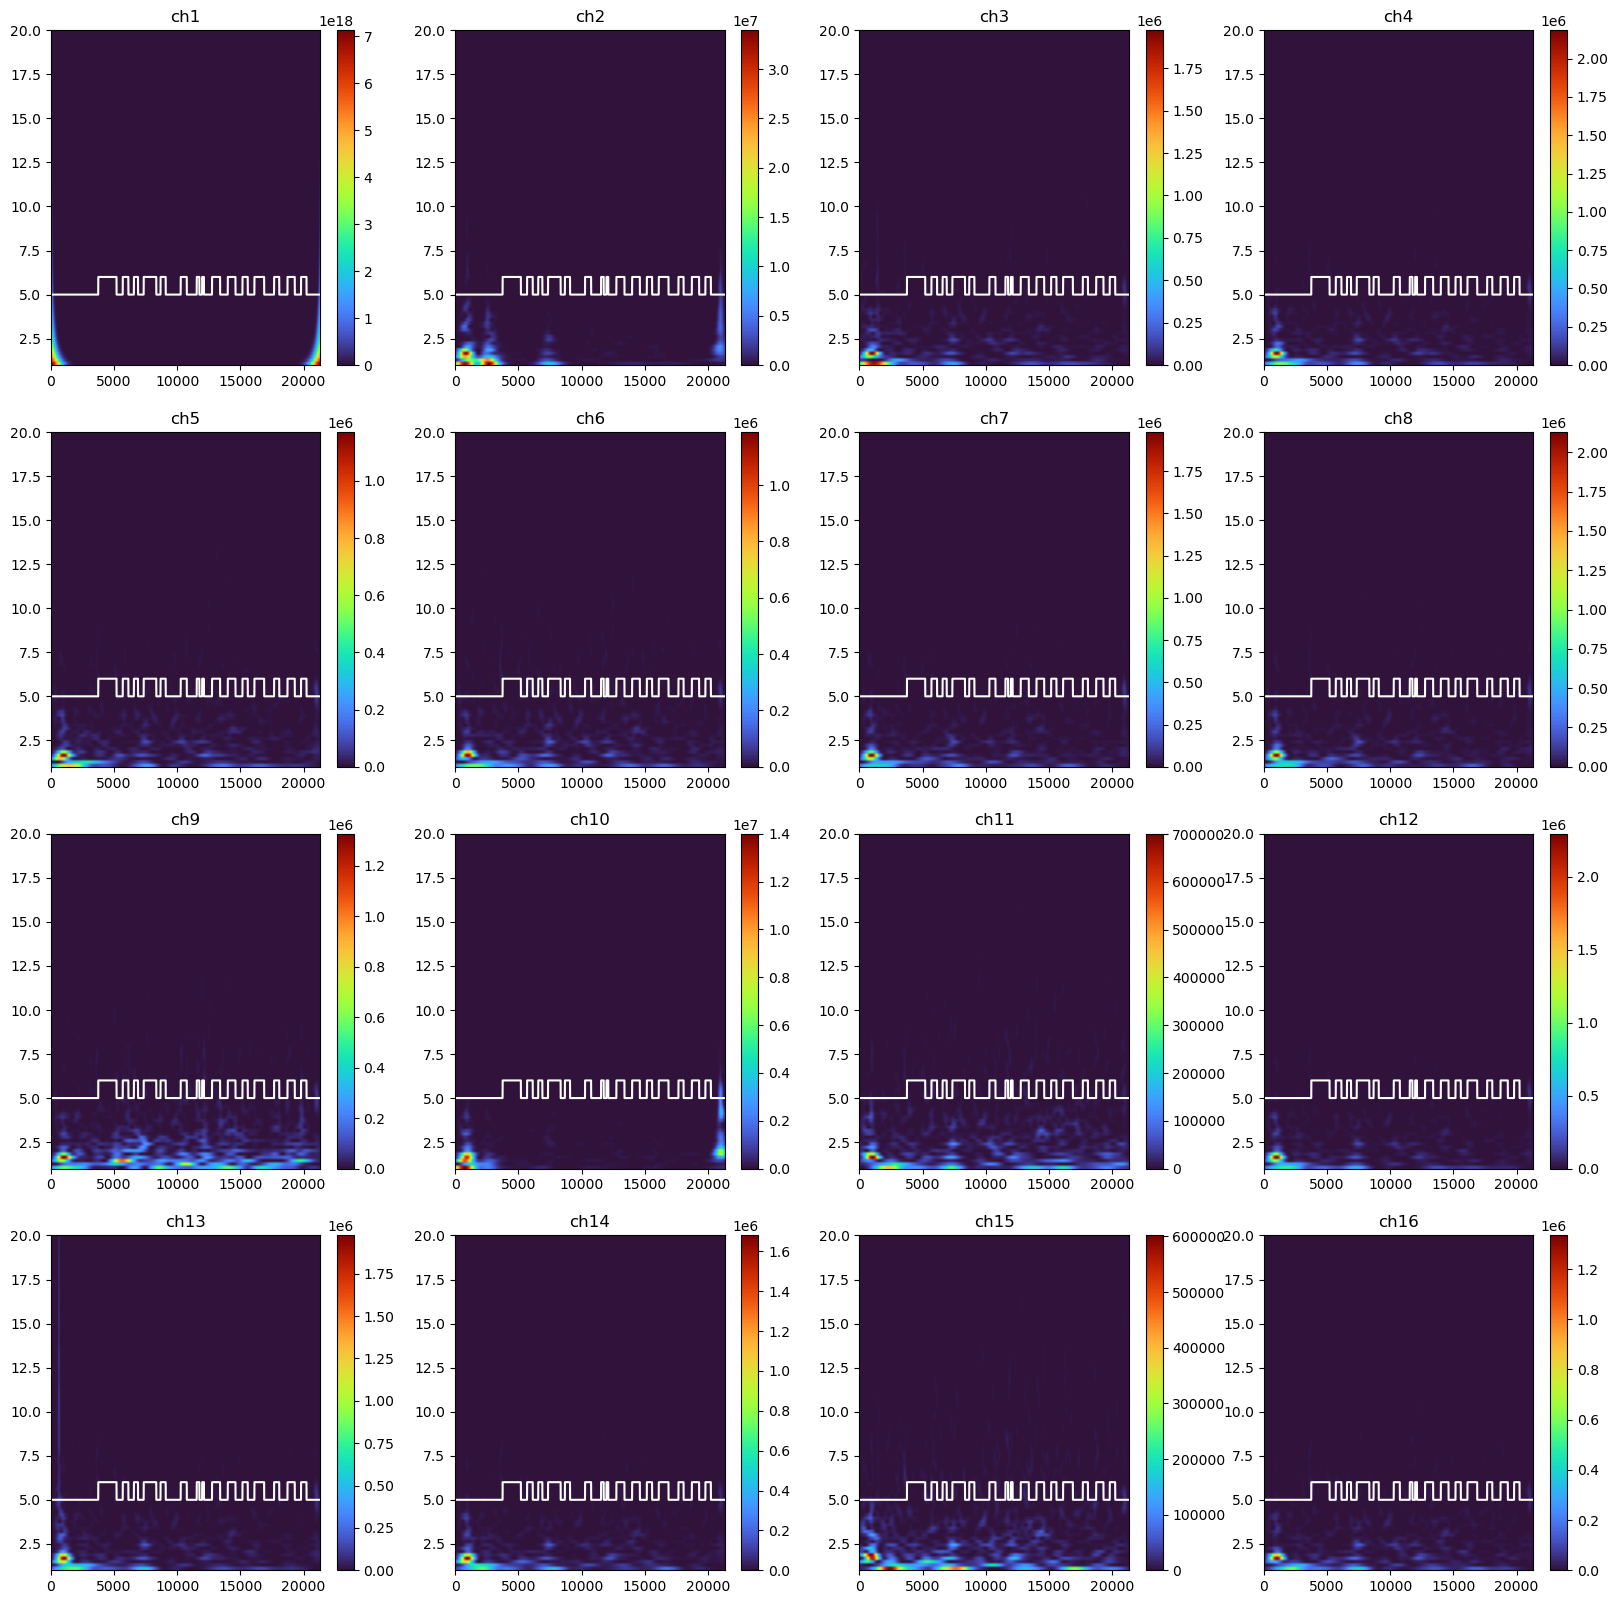

In [26]:
plt.figure(figsize=(20, 20))

for i in range(len(EEG_COLS)):
    plt.subplot(4, 4, i + 1)
    plt.imshow(
        W[i],
        aspect="auto",
        cmap="turbo",
        origin="lower",
        extent=[df.index.min(), df.index.max(), freqs.min(), freqs.max()],
    )
    plt.title(EEG_COLS[i])
    plt.colorbar()
    plt.plot(df.index, df.eyeDetection.astype(int) + 5, c="w")

### Build windowed dataset

In [27]:
def band_power(sig: np.ndarray, fs: int, fmin: float, fmax: float) -> float:
    """Compute average power in [fmin, fmax] Hz using Welch's method."""
    nperseg = min(len(sig), 64)
    freqs, psd = welch(sig, fs=fs, nperseg=nperseg)
    idx = np.logical_and(freqs >= fmin, freqs <= fmax)
    return float(float(psd[idx].sum() * (freqs[1] - freqs[0]) if len(freqs) > 1 else 0))


def extract_features(window: np.ndarray, fs: int = FS) -> np.ndarray:
    """
    window : (n_samples, n_channels)
    returns: 1-D feature vector
    """
    feats = []
    for ch in range(window.shape[1]):
        sig = window[:, ch]
        # Band powers
        for fmin, fmax in BANDS.values():
            feats.append(band_power(sig, fs, fmin, fmax))
        # Coefficient of variation
        mean = np.mean(sig)
        cv = np.std(sig) / mean if mean != 0 else 0.0
        feats.append(cv)
    return np.array(feats, dtype=np.float32)

In [28]:
print(f"Extracting features  (window={WIN_SEC}s  step={STEP_SEC}s) …")

X_raw = df[EEG_COLS].values.astype(np.float32)
y_raw = df[TARGET].values.astype(int)

windows, labels = [], []
starts = range(0, len(X_raw) - WIN_SAMP + 1, STEP_SAMP)

for i, start in enumerate(starts):
    end = start + WIN_SAMP
    win = X_raw[start:end]
    # label = int(y_raw[start:end].max())   # 1 if eye was OPEN at any point
    label = y_raw[start:end].any()
    windows.append(extract_features(win))
    labels.append(label)
    if (i + 1) % 50 == 0:
        print(f"  … {i+1}/{len(starts)} windows done", end="\r")

X = np.vstack(windows)
y = np.array(labels)
# y = np.random.permutation(y)
print(f"\n  Feature matrix: {X.shape}  |  Class balance: {np.bincount(y)}\n")

Extracting features  (window=2.0s  step=0.2s) …
  … 400/417 windows done
  Feature matrix: (417, 80)  |  Class balance: [113 304]



### Build feature names

In [29]:
feat_names = []
for ch in EEG_COLS:
    for band in BANDS:
        feat_names.append(f"{ch}_{band}_power")
    feat_names.append(f"{ch}_cv")

### Cross-validated Random Forest

In [30]:
print("Training Random Forest (5-fold stratified CV) …")

clf = RandomForestClassifier(
    n_estimators=1000,
    max_depth=None,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced",
    n_jobs=-1,
    random_state=42,
)

Training Random Forest (5-fold stratified CV) …


In [31]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["accuracy", "f1_weighted", "roc_auc"]

cv_results = cross_validate(clf, X, y, cv=cv, scoring=scoring, return_train_score=True)

print("\n── Cross-Validation Results ──────────────────────────")
for metric in scoring:
    tr = cv_results[f"train_{metric}"]
    te = cv_results[f"test_{metric}"]
    print(
        f"  {metric:14s}  train {tr.mean():.4f}±{tr.std():.4f}"
        f"  │  test {te.mean():.4f}±{te.std():.4f}"
    )


── Cross-Validation Results ──────────────────────────
  accuracy        train 1.0000±0.0000  │  test 0.9087±0.0284
  f1_weighted     train 1.0000±0.0000  │  test 0.9013±0.0335
  roc_auc         train 1.0000±0.0000  │  test 0.9782±0.0134


### Final model on full data for feature importance & confusion matrix

In [32]:
print("\nFitting final model on full dataset …")
clf.fit(X, y)
y_pred = clf.predict(X)
y_prob = clf.predict_proba(X)[:, 1]

print("\n── Full-data Classification Report ──────────────────")
print(classification_report(y, y_pred, target_names=["Closed", "Open"]))


Fitting final model on full dataset …

── Full-data Classification Report ──────────────────
              precision    recall  f1-score   support

      Closed       1.00      1.00      1.00       113
        Open       1.00      1.00      1.00       304

    accuracy                           1.00       417
   macro avg       1.00      1.00      1.00       417
weighted avg       1.00      1.00      1.00       417



### Plots

Generating plots …
Plot saved → eeg_classifier_results.png

✓ Done.


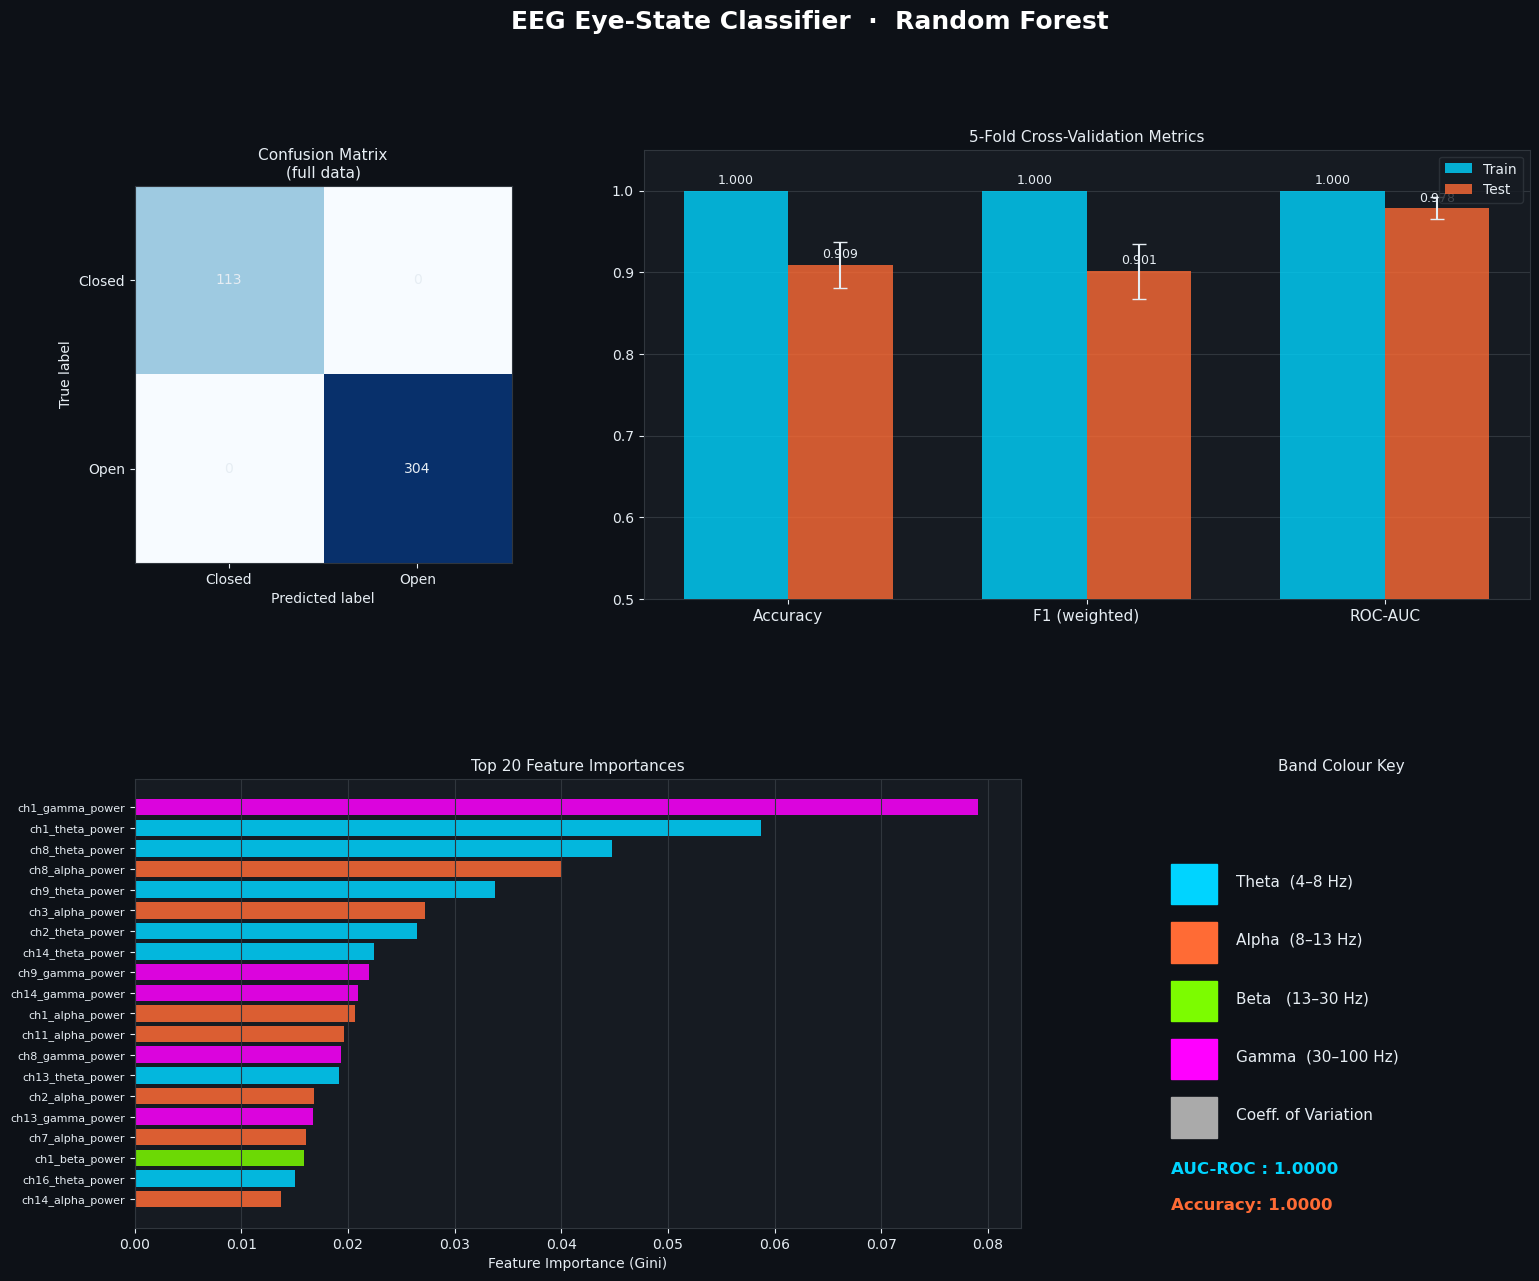

In [33]:
print("Generating plots …")

fig = plt.figure(figsize=(18, 14), facecolor="#0d1117")
fig.suptitle(
    "EEG Eye-State Classifier  ·  Random Forest",
    fontsize=18,
    color="white",
    fontweight="bold",
    y=0.98,
)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

ax_cm = fig.add_subplot(gs[0, 0])
ax_cv = fig.add_subplot(gs[0, 1:])
ax_bp = fig.add_subplot(gs[1, :2])
ax_leg = fig.add_subplot(gs[1, 2])

DARK = "#0d1117"
CARD = "#161b22"
NEON = ["#00d4ff", "#ff6b35", "#7cfc00", "#ff00ff"]
WHITE = "#e6edf3"
GRAY = "#8b949e"

for ax in [ax_cm, ax_cv, ax_bp, ax_leg]:
    ax.set_facecolor(CARD)
    for spine in ax.spines.values():
        spine.set_color("#30363d")

# ── 8a. Confusion Matrix ─────────────────────
cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Closed", "Open"])
disp.plot(ax=ax_cm, colorbar=False, cmap="Blues")
ax_cm.set_title("Confusion Matrix\n(full data)", color=WHITE, fontsize=11)
ax_cm.tick_params(colors=WHITE)
ax_cm.xaxis.label.set_color(WHITE)
ax_cm.yaxis.label.set_color(WHITE)
for text in ax_cm.texts:
    text.set_color(WHITE)

# ── 8b. CV metrics bar chart ─────────────────
metrics_labels = ["Accuracy", "F1 (weighted)", "ROC-AUC"]
test_means = [cv_results[f"test_{m}"].mean() for m in scoring]
test_stds = [cv_results[f"test_{m}"].std() for m in scoring]
train_means = [cv_results[f"train_{m}"].mean() for m in scoring]

x = np.arange(len(metrics_labels))
w = 0.35
bars_tr = ax_cv.bar(
    x - w / 2, train_means, w, label="Train", color="#00d4ff", alpha=0.8, zorder=3
)
bars_te = ax_cv.bar(
    x + w / 2,
    test_means,
    w,
    label="Test",
    color="#ff6b35",
    alpha=0.8,
    yerr=test_stds,
    capsize=5,
    error_kw=dict(ecolor=WHITE, lw=1.5),
    zorder=3,
)
ax_cv.set_xticks(x)
ax_cv.set_xticklabels(metrics_labels, color=WHITE, fontsize=11)
ax_cv.set_ylim(0.5, 1.05)
ax_cv.set_title("5-Fold Cross-Validation Metrics", color=WHITE, fontsize=11)
ax_cv.tick_params(colors=WHITE)
ax_cv.yaxis.grid(True, color="#30363d", zorder=0)
ax_cv.legend(facecolor=CARD, labelcolor=WHITE, edgecolor="#30363d")
for bar in list(bars_tr) + list(bars_te):
    ax_cv.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{bar.get_height():.3f}",
        ha="center",
        va="bottom",
        color=WHITE,
        fontsize=9,
    )

# ── 8c. Top-20 feature importances ───────────
imp = clf.feature_importances_
top_idx = np.argsort(imp)[-20:]
top_names = [feat_names[i] for i in top_idx]
top_vals = imp[top_idx]

# colour by band
band_colours = {
    "theta": NEON[0],
    "alpha": NEON[1],
    "beta": NEON[2],
    "gamma": NEON[3],
    "cv": "#aaaaaa",
}

bar_colours = []
for name in top_names:
    for band_key, col in band_colours.items():
        if band_key in name:
            bar_colours.append(col)
            break

ax_bp.barh(range(20), top_vals, color=bar_colours, alpha=0.85)
ax_bp.set_yticks(range(20))
ax_bp.set_yticklabels(top_names, color=WHITE, fontsize=8)
ax_bp.set_xlabel("Feature Importance (Gini)", color=WHITE)
ax_bp.set_title("Top 20 Feature Importances", color=WHITE, fontsize=11)
ax_bp.tick_params(colors=WHITE)
ax_bp.xaxis.grid(True, color="#30363d", zorder=0)

# ── 8d. Legend panel ─────────────────────────
ax_leg.axis("off")
legend_items = [
    (NEON[0], "Theta  (4–8 Hz)"),
    (NEON[1], "Alpha  (8–13 Hz)"),
    (NEON[2], "Beta   (13–30 Hz)"),
    (NEON[3], "Gamma  (30–100 Hz)"),
    ("#aaaaaa", "Coeff. of Variation"),
]
for i, (col, label) in enumerate(legend_items):
    ax_leg.add_patch(
        plt.Rectangle(
            (0.05, 0.72 - i * 0.13), 0.12, 0.09, color=col, transform=ax_leg.transAxes
        )
    )
    ax_leg.text(
        0.22,
        0.77 - i * 0.13,
        label,
        transform=ax_leg.transAxes,
        color=WHITE,
        fontsize=11,
        va="center",
    )

ax_leg.set_title("Band Colour Key", color=WHITE, fontsize=11)

# summary stats
auc_str = f"AUC-ROC : {roc_auc_score(y, y_prob):.4f}"
acc_str = f"Accuracy: {(y==y_pred).mean():.4f}"
ax_leg.text(
    0.05,
    0.12,
    auc_str,
    transform=ax_leg.transAxes,
    color=NEON[0],
    fontsize=12,
    fontweight="bold",
)
ax_leg.text(
    0.05,
    0.04,
    acc_str,
    transform=ax_leg.transAxes,
    color=NEON[1],
    fontsize=12,
    fontweight="bold",
)

# plt.savefig("/mnt/user-data/outputs/eeg_classifier_results.png",
#            dpi=150, bbox_inches="tight", facecolor=DARK)
print("Plot saved → eeg_classifier_results.png")

# ─────────────────────────────────────────────
# 9.  Save the script itself for reference
# ─────────────────────────────────────────────
print("\n✓ Done.")